# Complete Example

In [1]:
from musicnpy import *
from IPython.display import Image

## Esempio 1
Partendo da due scale differenti, creare un morphing tra le due per generare un profilo melodico. Creare l'armonizzazione delle due scale in maniera separata. Ad ogni ciclo di ripetizione della melodia prendere due accordi delle armonizzazioni e generare un morphing tra i due con diverse modalità, random, up, down e chiasmo.

Changing working directory to: `./images'
Processing `./images/chiasmo.ly'
Parsing...
Interpreting music...[8][16]
Preprocessing graphical objects...
Interpreting music...
MIDI output to `chiasmo.midi'...
Finding the ideal number of pages...
Fitting music on 1 or 2 pages...
Drawing systems...
Converting to PNG...
Success: compilation successfully completed


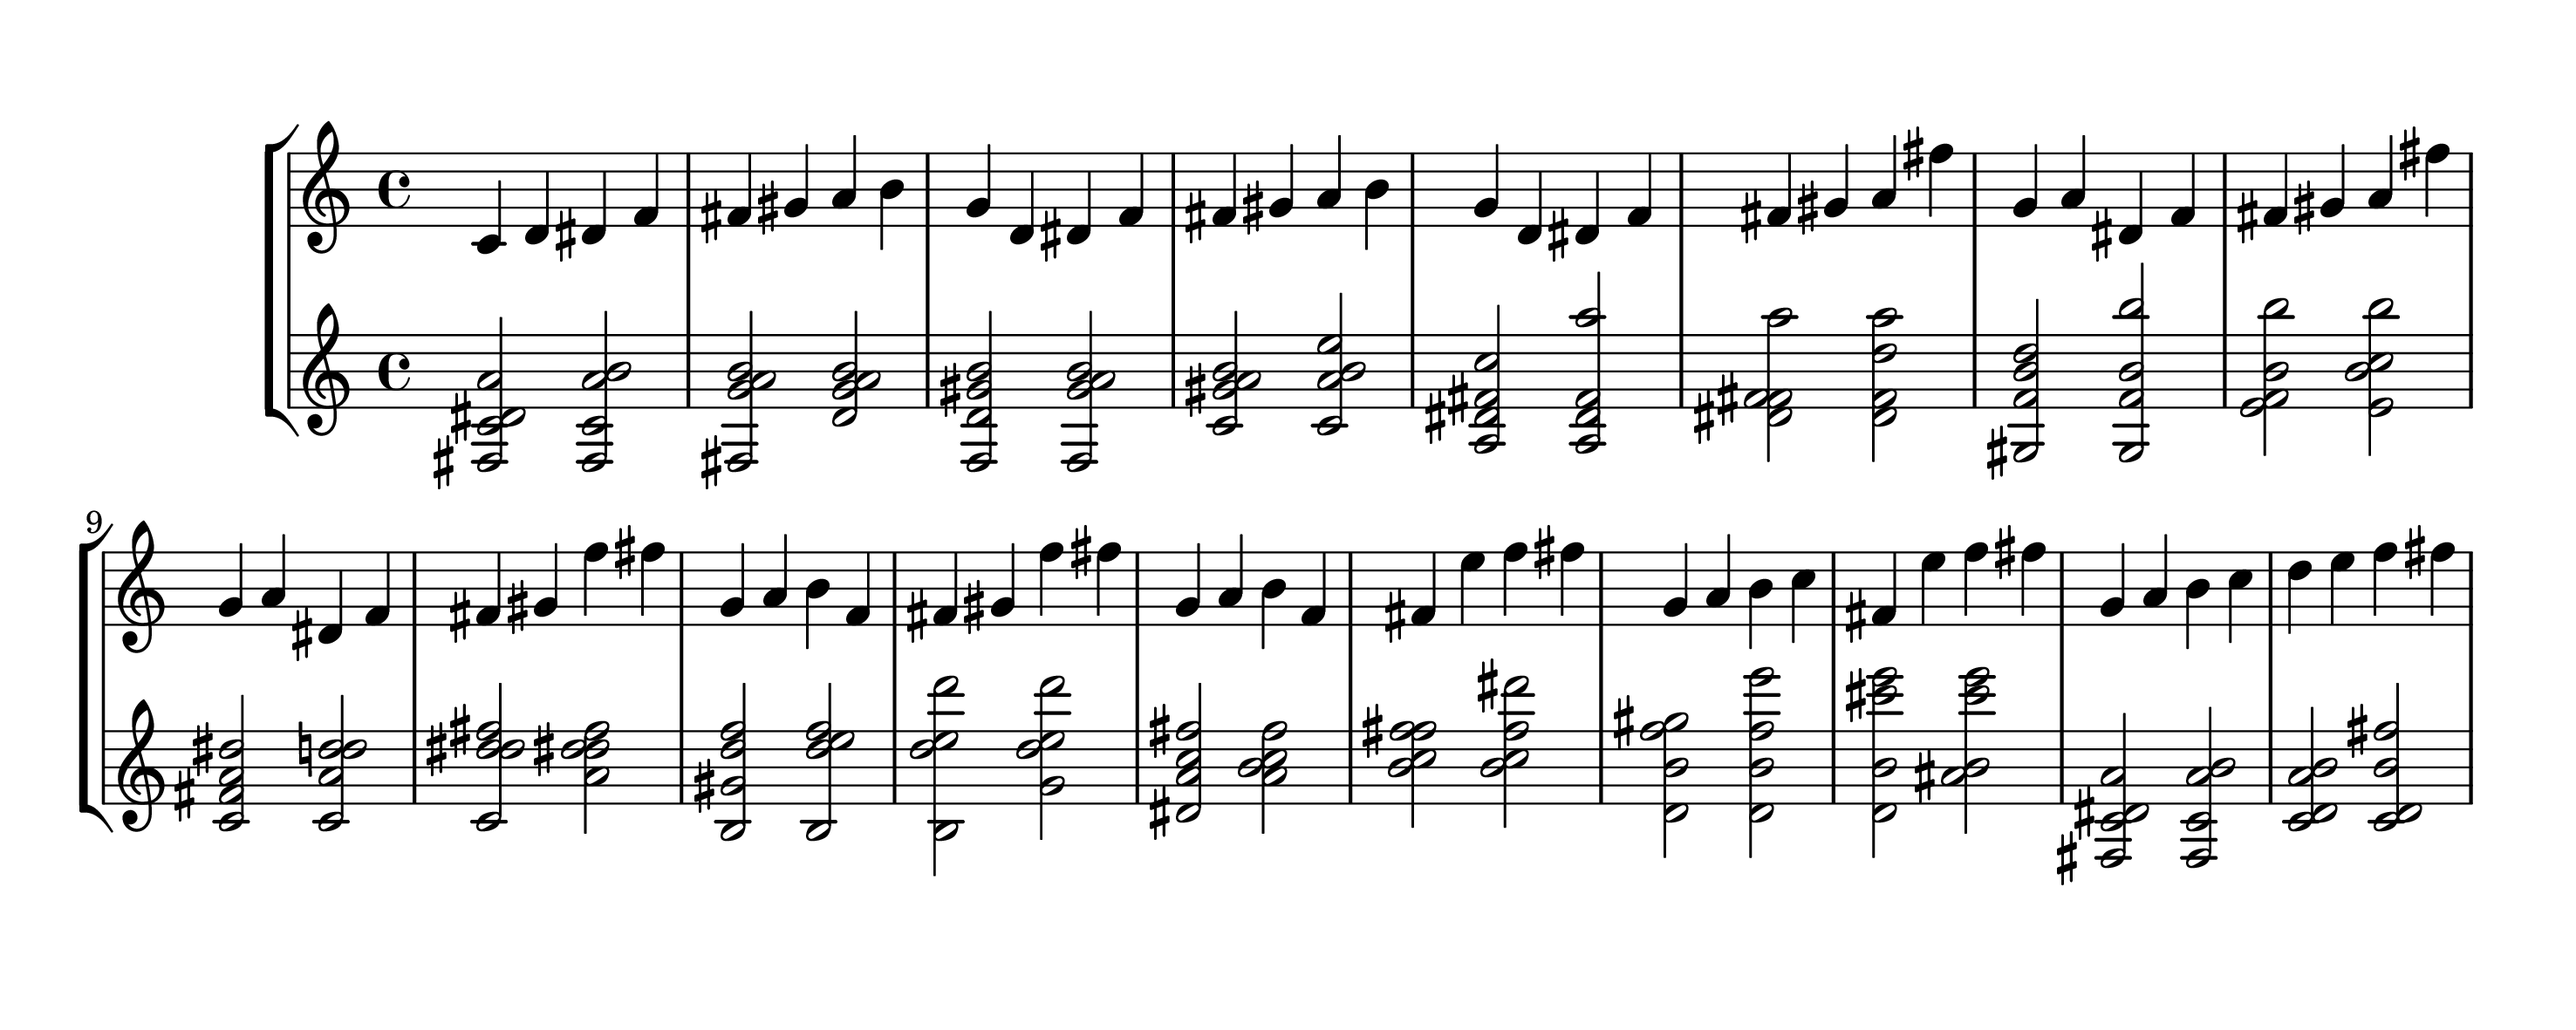

In [2]:
a = Scale.new(ScaleModel.dimWholeHalf, 60)
b = Scale.new(ScaleModel.bebop, 67)

chiasmoNote = a.morphing(b, 'chiasm')

chord_a = a.harmonize
chord_b = b.harmonize

chords = []

mode = ['rand', 'up', 'down', 'rand', 'up', 'chiasm', 'rand', 'down']
drop = ['drop2', 'drop3']*8

for i in enumerate(chiasmoNote):
    id = i[0]%8
    morphed = chord_a[id].morphing(chord_b[id], mode[id])[:-1]
    for c in morphed:
        bar_chord = getattr(c, drop[id % 2])
        chords.append(bar_chord)

seq_1 = PitchSequence((chiasmoNote)).out
seq_2 = PitchSequence((chords)).out

seq_1 = Staff(seq_1, 4, 90).out
seq_2 = Staff(seq_2, 2, 90, clef='bass', i_name='').out

Score((seq_1, seq_2), filename='./images/chiasmo', format='png', size=(250, 100)).make_file
Image(filename='./images/chiasmo.png')

## Esempio 2
Partendo da una seire armonica, creare una modulazione ad anello con una frequenza modulante a scelta. Creare uno spartito con l'accordo della modulzione ad anello di durata 2 quarti e la scala ascendente in semitoni dell'accordo.

Changing working directory to: `./images'
Processing `./images/rm_1.ly'
Parsing...
Interpreting music...[8][16][24][32]
Preprocessing graphical objects...
Interpreting music...
MIDI output to `rm_1.midi'...
Finding the ideal number of pages...
Fitting music on 1 page...
Drawing systems...
Converting to PNG...
Success: compilation successfully completed


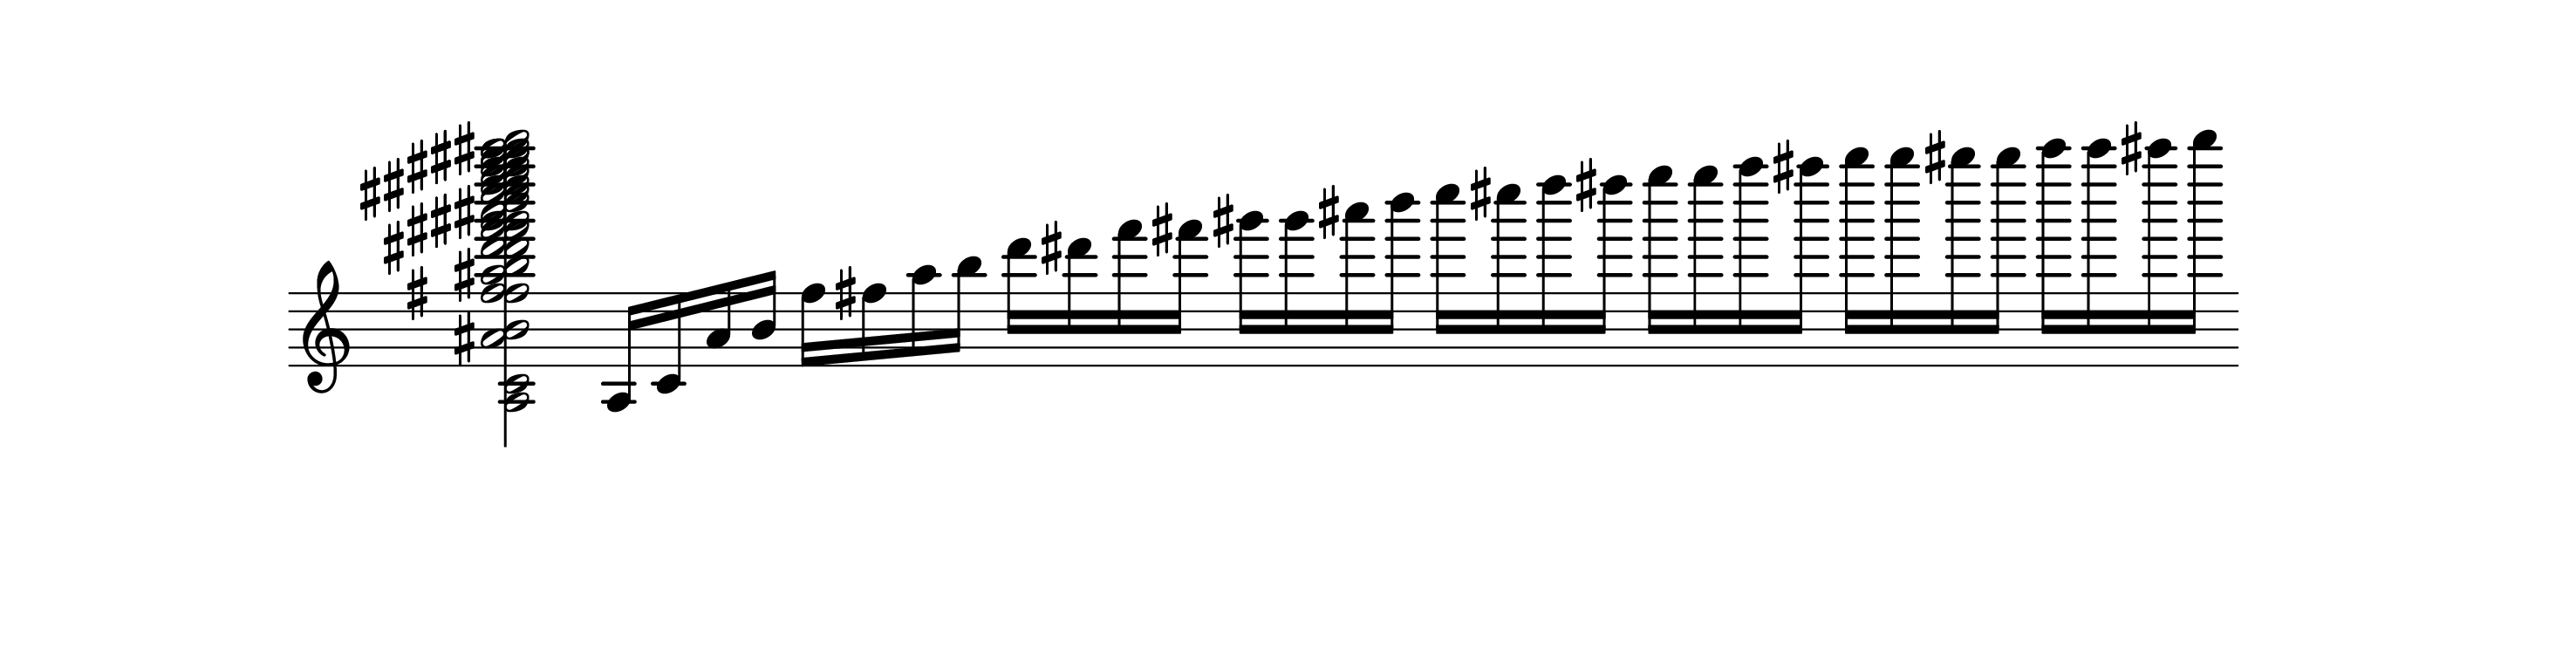

In [3]:
a = Spectra.harm_series(240, 16, 1)
b = a.ring_mod(21.1234)
crd = Chord.from_freq(b).micro_quanta(1)
scl = Scale.from_freq(b).micro_quanta(1)

seq = PitchSequence((crd, scl)).out
dur = [2, 16]
voce = Staff(seq, dur, 90).out
Score(voce, filename='./images/rm_1', format='png', size=(250, 65)).sei_libero().make_file
Image(filename='./images/rm_1.png')

## Esempio 3

Changing working directory to: `./images'
Processing `./images/rm_2.ly'
Parsing...
Interpreting music...
Preprocessing graphical objects...
Interpreting music...
MIDI output to `rm_2.midi'...
Finding the ideal number of pages...
Fitting music on 1 page...
Drawing systems...
Converting to PNG...
Success: compilation successfully completed


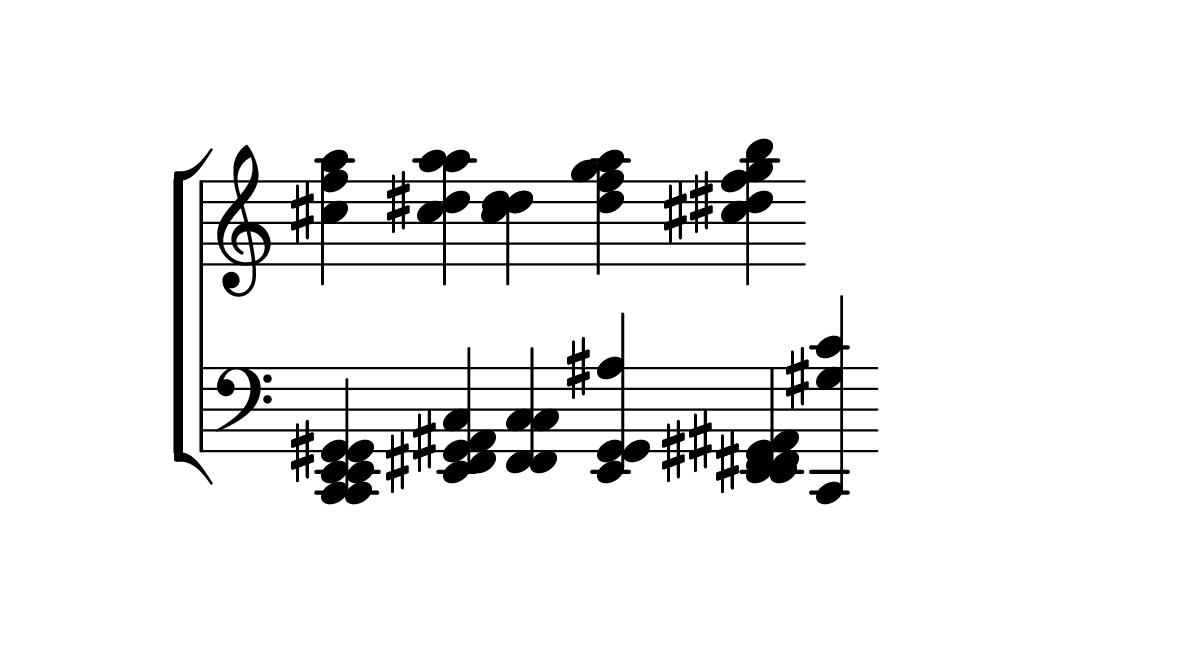

In [4]:
chords = [ChordModel.aug,
          ChordModel.dim7,
          ChordModel.german_aug6,
          ChordModel.quintal,
          ChordModel.dom_b9,
          ChordModel.quartal] # max 12

roots = Scale.new(ScaleModel.chromatic, 36)

mods = [0.4, 12, 2.523, 155.1234, 550.123, 55.12345]

seq_odd = []
seq_even = []

for i in range(len(chords)):
    a = Chord.new(chords[i], roots[i])
    rm = Spectra.to_ring_mod(a, mods[i])
    rmChord = Chord.from_freq(rm.vals).micro_quanta(1)
    seq_odd.append(Chord(rmChord.odd).to_range(72, 96))
    seq_even.append(Chord(rmChord.even).to_range(36, 60))

seq_odd = PitchSequence(seq_odd).out
seq_even = PitchSequence(seq_even).out

a = Staff(seq_odd, 4, 90).out
b = Staff(seq_even, 4, 90, clef='bass').out

Score((a, b), filename='./images/rm_2', format='png', size=(100, 55)).sei_libero().make_file
Image(filename='./images/rm_2.png')

## Esempio 3
Generare due spettri con fondamentali diverse con 8 armonici ciascuno. Prendere uno spettro e calcolare delle scale partendo modulando lo spettro identificato con tutti i parziali dell'altro. Riscalare e togliere le ripetizioni all'interno delle scale. 

Changing working directory to: `./images'
Processing `./images/rm_scales.ly'
Parsing...
Interpreting music...[8][16]
Preprocessing graphical objects...
Interpreting music...
MIDI output to `rm_scales.midi'...
Finding the ideal number of pages...
Fitting music on 15 or 16 pages...
Drawing systems...
Converting to PNG...
Success: compilation successfully completed


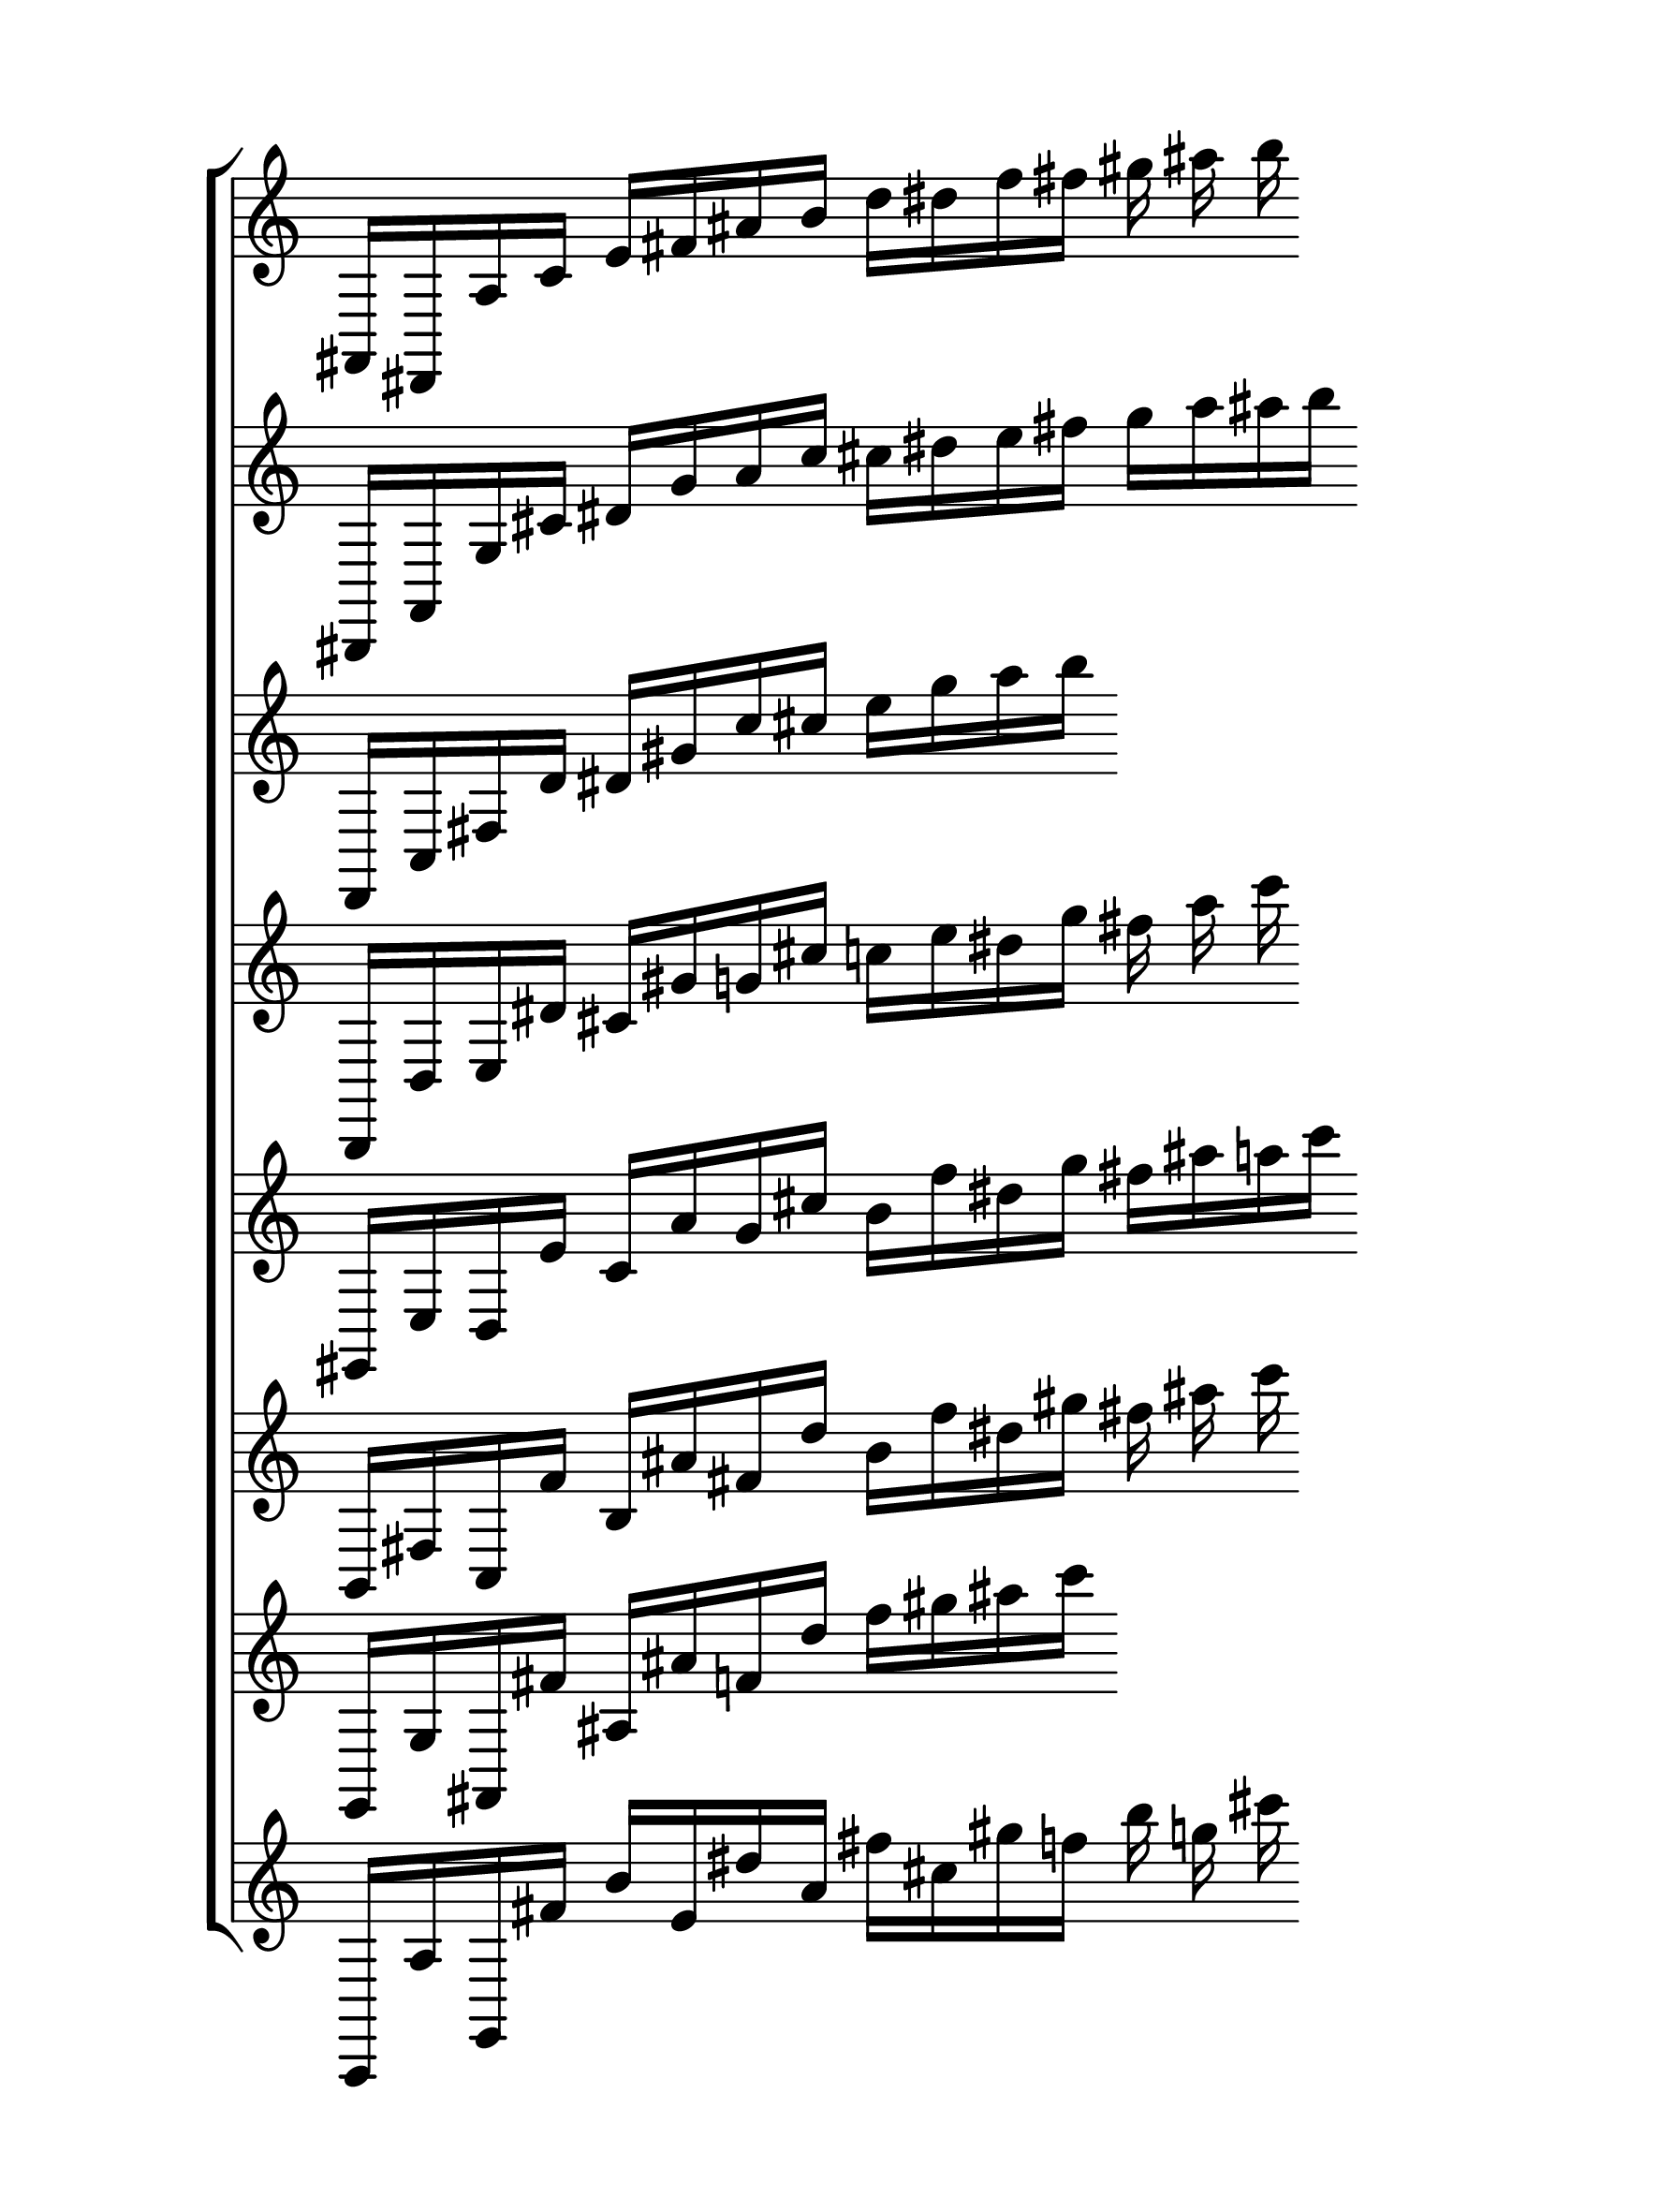

In [5]:
N_HARMS = 8

a = Spectra.harm_series(55, N_HARMS, 1)
b = Spectra.harm_series(75, N_HARMS, 1.5784)

seq = []

for i in enumerate(a):
    id, item = i[0], i[1]
    ring = b.ring_mod(a[id]/3.1234)
    scale = Scale.from_freq(ring.values).micro_quanta(1).to_range(36, 92).unique()
    voce = Staff(scale.values, 16, 90).out
    seq.append(voce)

Score(tuple(seq), filename='./images/rm_scales', format='png', size=(10, 200)).sei_libero().make_file
Image(filename='./images/rm_scales.png')

## Esempio 4

Changing working directory to: `./images'
Processing `./images/scale.ly'
Parsing...
Interpreting music...
Preprocessing graphical objects...
Interpreting music...
MIDI output to `scale.midi'...
Finding the ideal number of pages...
Fitting music on 1 page...
Drawing systems...
Converting to PNG...
Success: compilation successfully completed


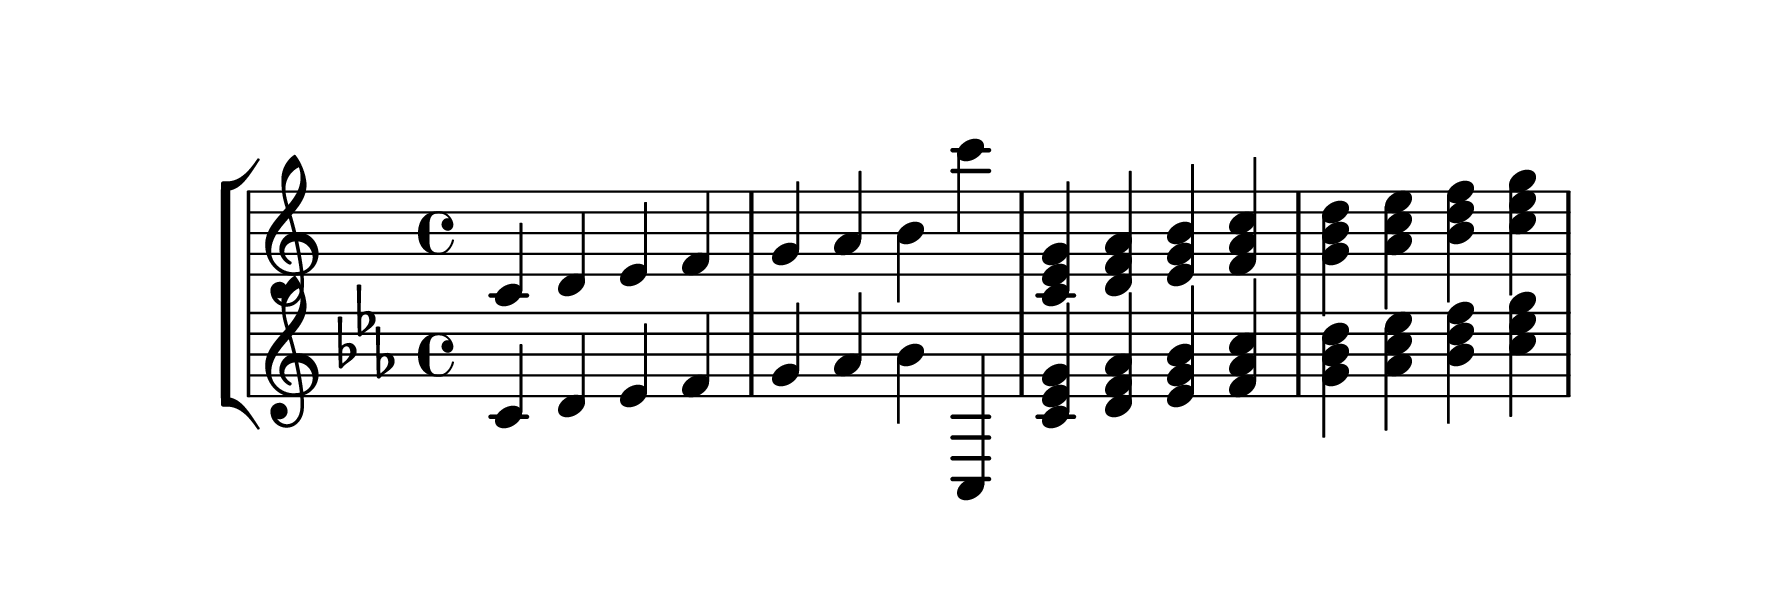

In [6]:
doMaj = Scale.new(ScaleModel.maj, 60)
doMin = Scale.new(ScaleModel.minNat, 60)

seq_1 = PitchSequence((doMaj, 84, doMaj.harmonize, Chord.new(ChordModel.maj, 72))).out
seq_2 = PitchSequence((doMin, 48, doMin.harmonize, Chord.new(ChordModel.min, 72))).out

staff_1 = Staff(seq_1, 4, 90).out
staff_2 = Staff(seq_2, 4, 90, key='ef').out

Score((staff_1, staff_2), filename='./images/scale', format='png', size=(150, 50)).make_file
Image(filename='./images/scale.png')

## Esempio 5

Changing working directory to: `./images'
Processing `./images/interpolazionelunga.ly'
Parsing...
Interpreting music...[8][16][24]
Preprocessing graphical objects...
Finding the ideal number of pages...
Fitting music on 1 page...
Drawing systems...
Converting to PNG...
Success: compilation successfully completed


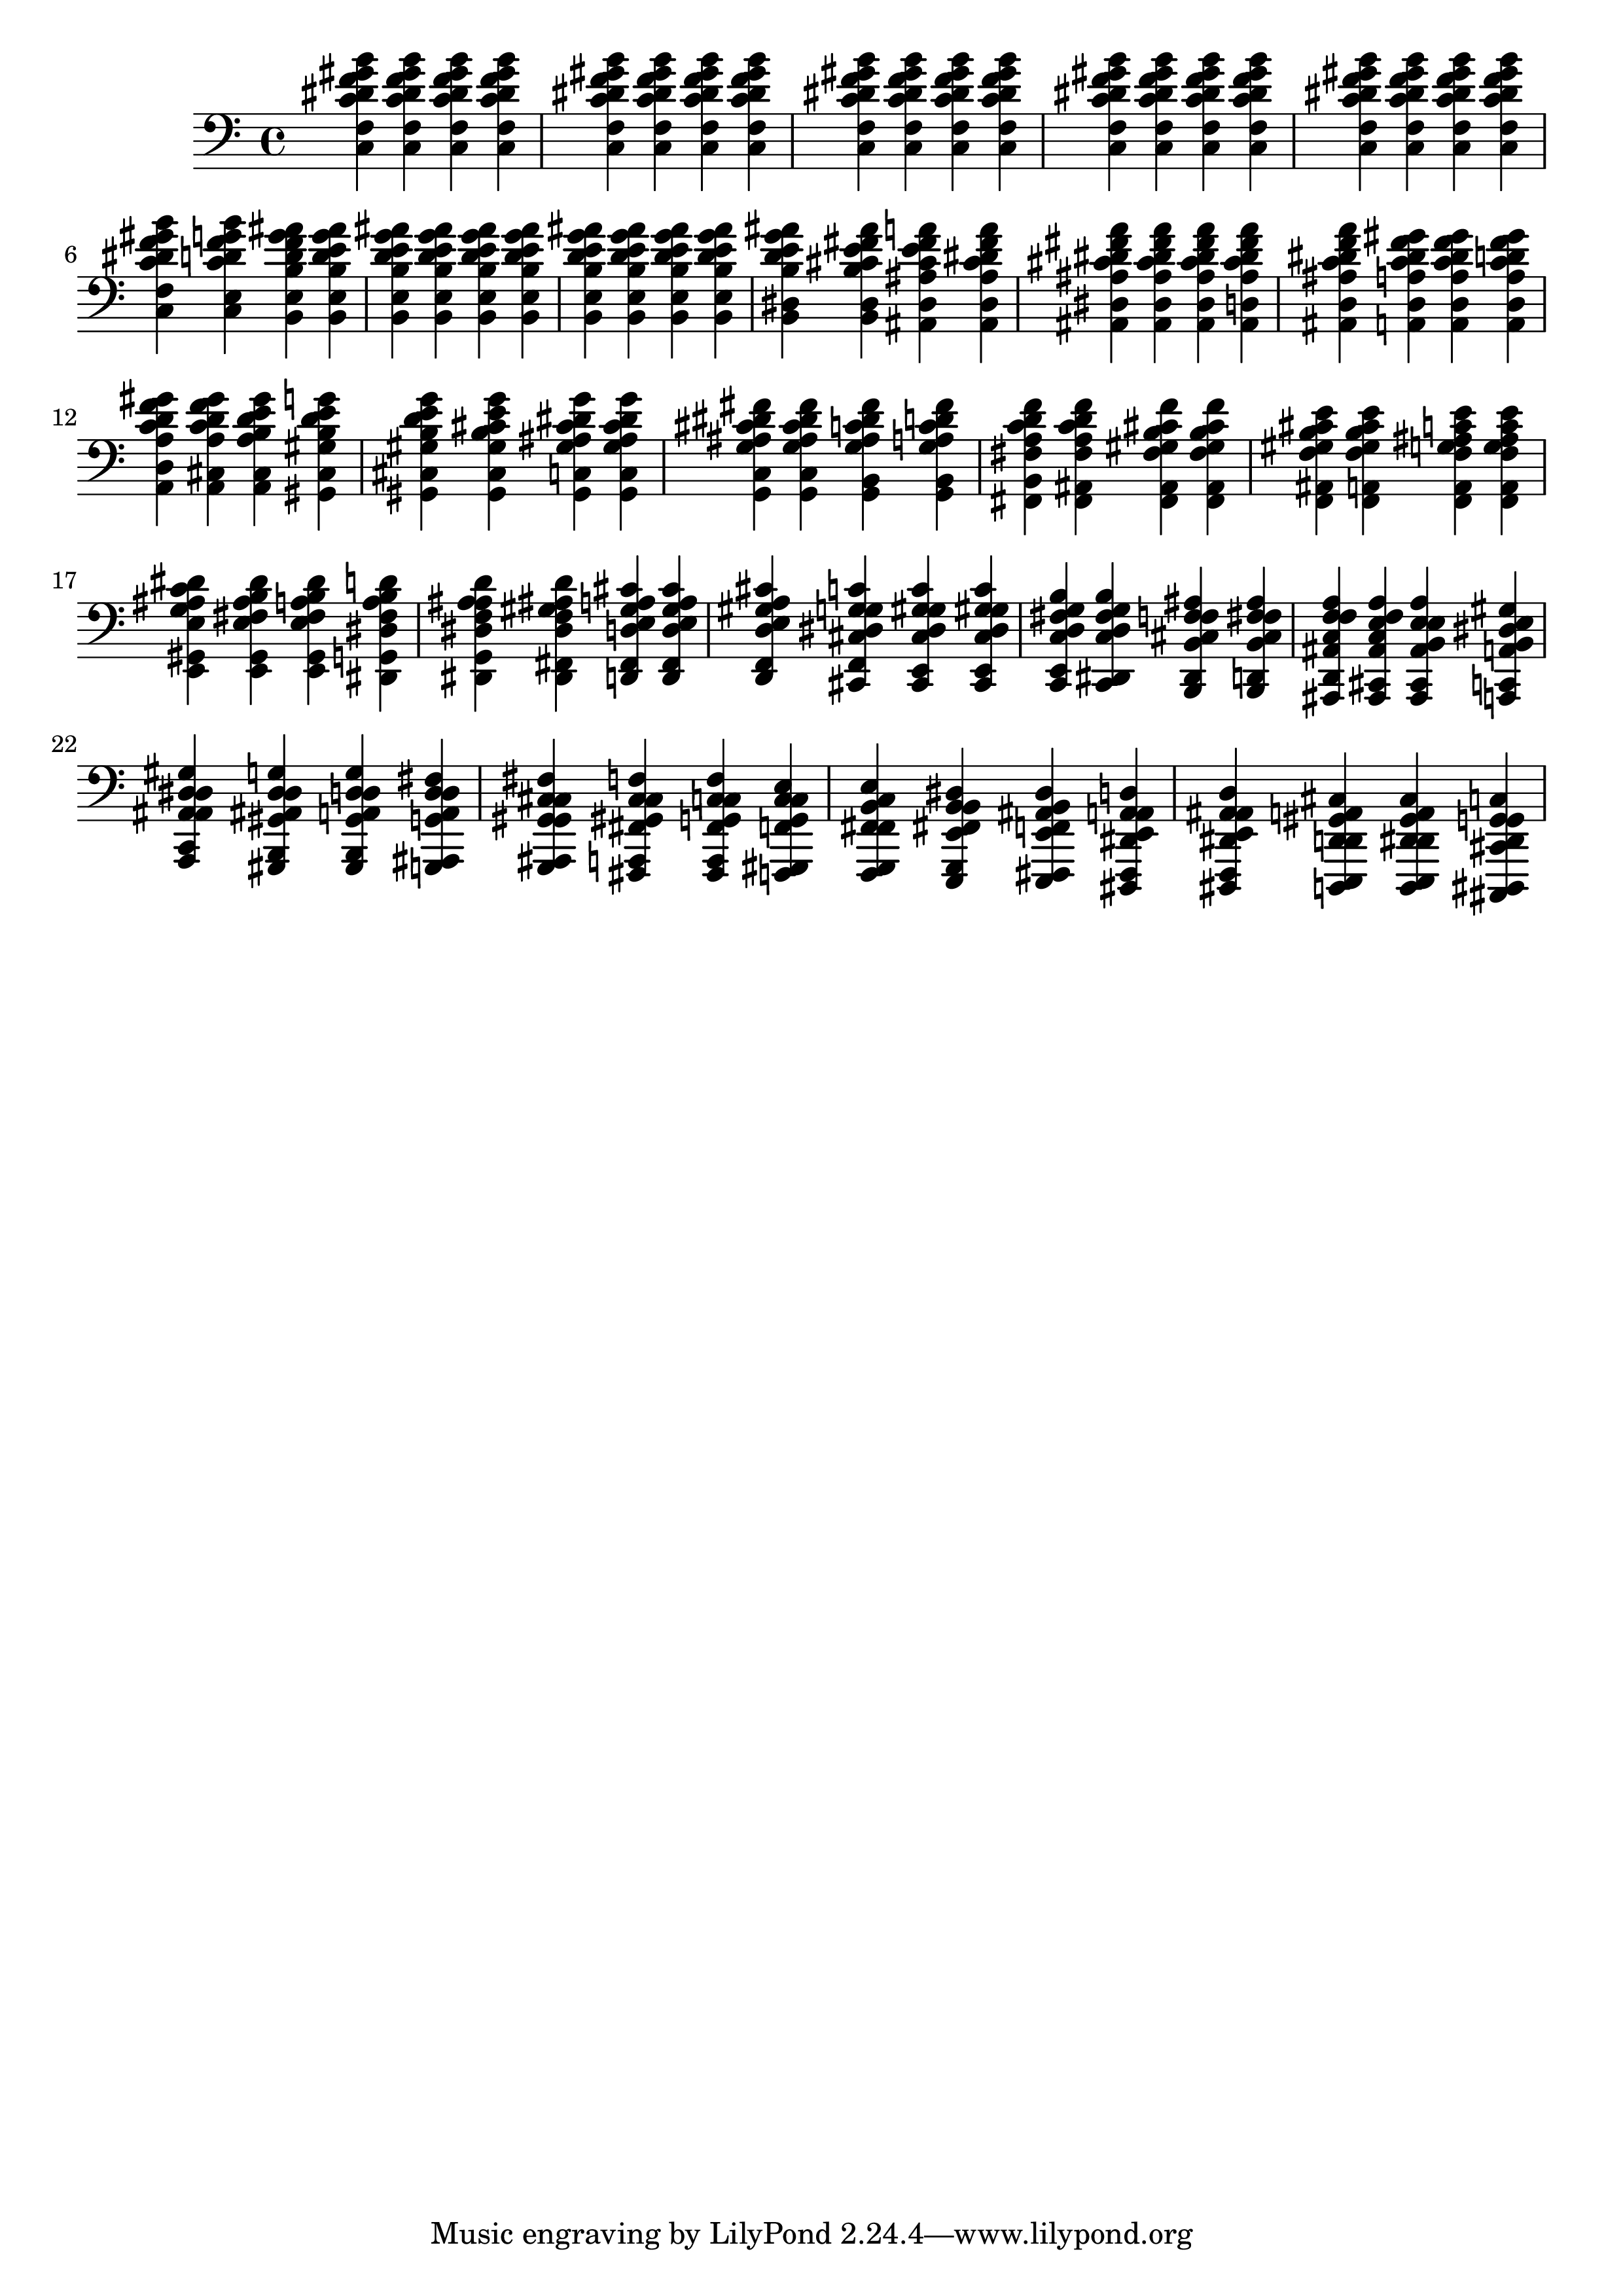

In [7]:
a = Chord([-12, -7, 0, 3, 5, 8, 11], 60)
b = Chord([-11, -9, 1, 2, 8, 7, 12], 36)

interp = a.interpolation(b, 100, 2.5)
interp = [c.round() for c in interp]


seq_3 = PitchSequence(interp).out

Staff(seq_3, 4, 90, clef='bass', filename='./images/interpolazionelunga', format='png').make_file
Image(filename='./images/interpolazionelunga.png')

## Esempio 6

Changing working directory to: `./images'
Processing `./images/intepolazione_dura.ly'
Parsing...
Interpreting music...[8]
Preprocessing graphical objects...
Interpreting music...
MIDI output to `intepolazione_dura.midi'...
Finding the ideal number of pages...
Fitting music on 1 page...
Drawing systems...
Converting to PNG...
Success: compilation successfully completed


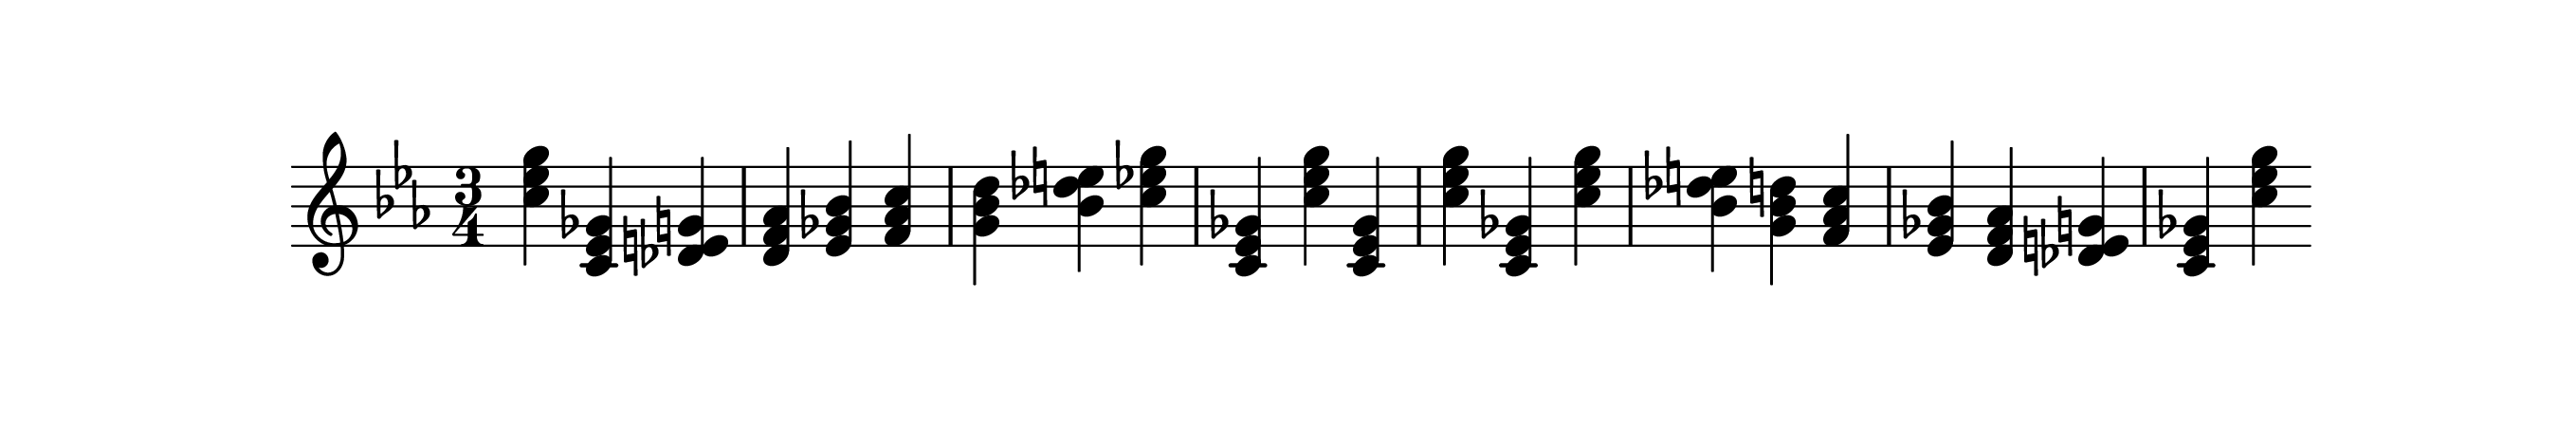

In [8]:
a = Chord(ChordModel.dim, 60)
b = Chord(ChordModel.min, 72)

interp = a.interpolation(b, 8, 1.5, 0)
reverseInterp = interp[::-1]

seq = PitchSequence((b, interp, a, b, a, b, a, reverseInterp, b))

o = Staff(seq.out, 4, 90, t_sig='3/4', key='ef').out

Score(o, filename='./images/intepolazione_dura', format='png', size=(230, 40)).make_file #perchè non va....
Image(filename='./images/intepolazione_dura.png')

## Esempio 7

Changing working directory to: `./images'
Processing `./images/faMaggiore.ly'
Parsing...
Interpreting music...[8][16]
Preprocessing graphical objects...
Interpreting music...
MIDI output to `faMaggiore.midi'...
Finding the ideal number of pages...
Fitting music on 1 page...
Drawing systems...
Converting to PNG...
Success: compilation successfully completed


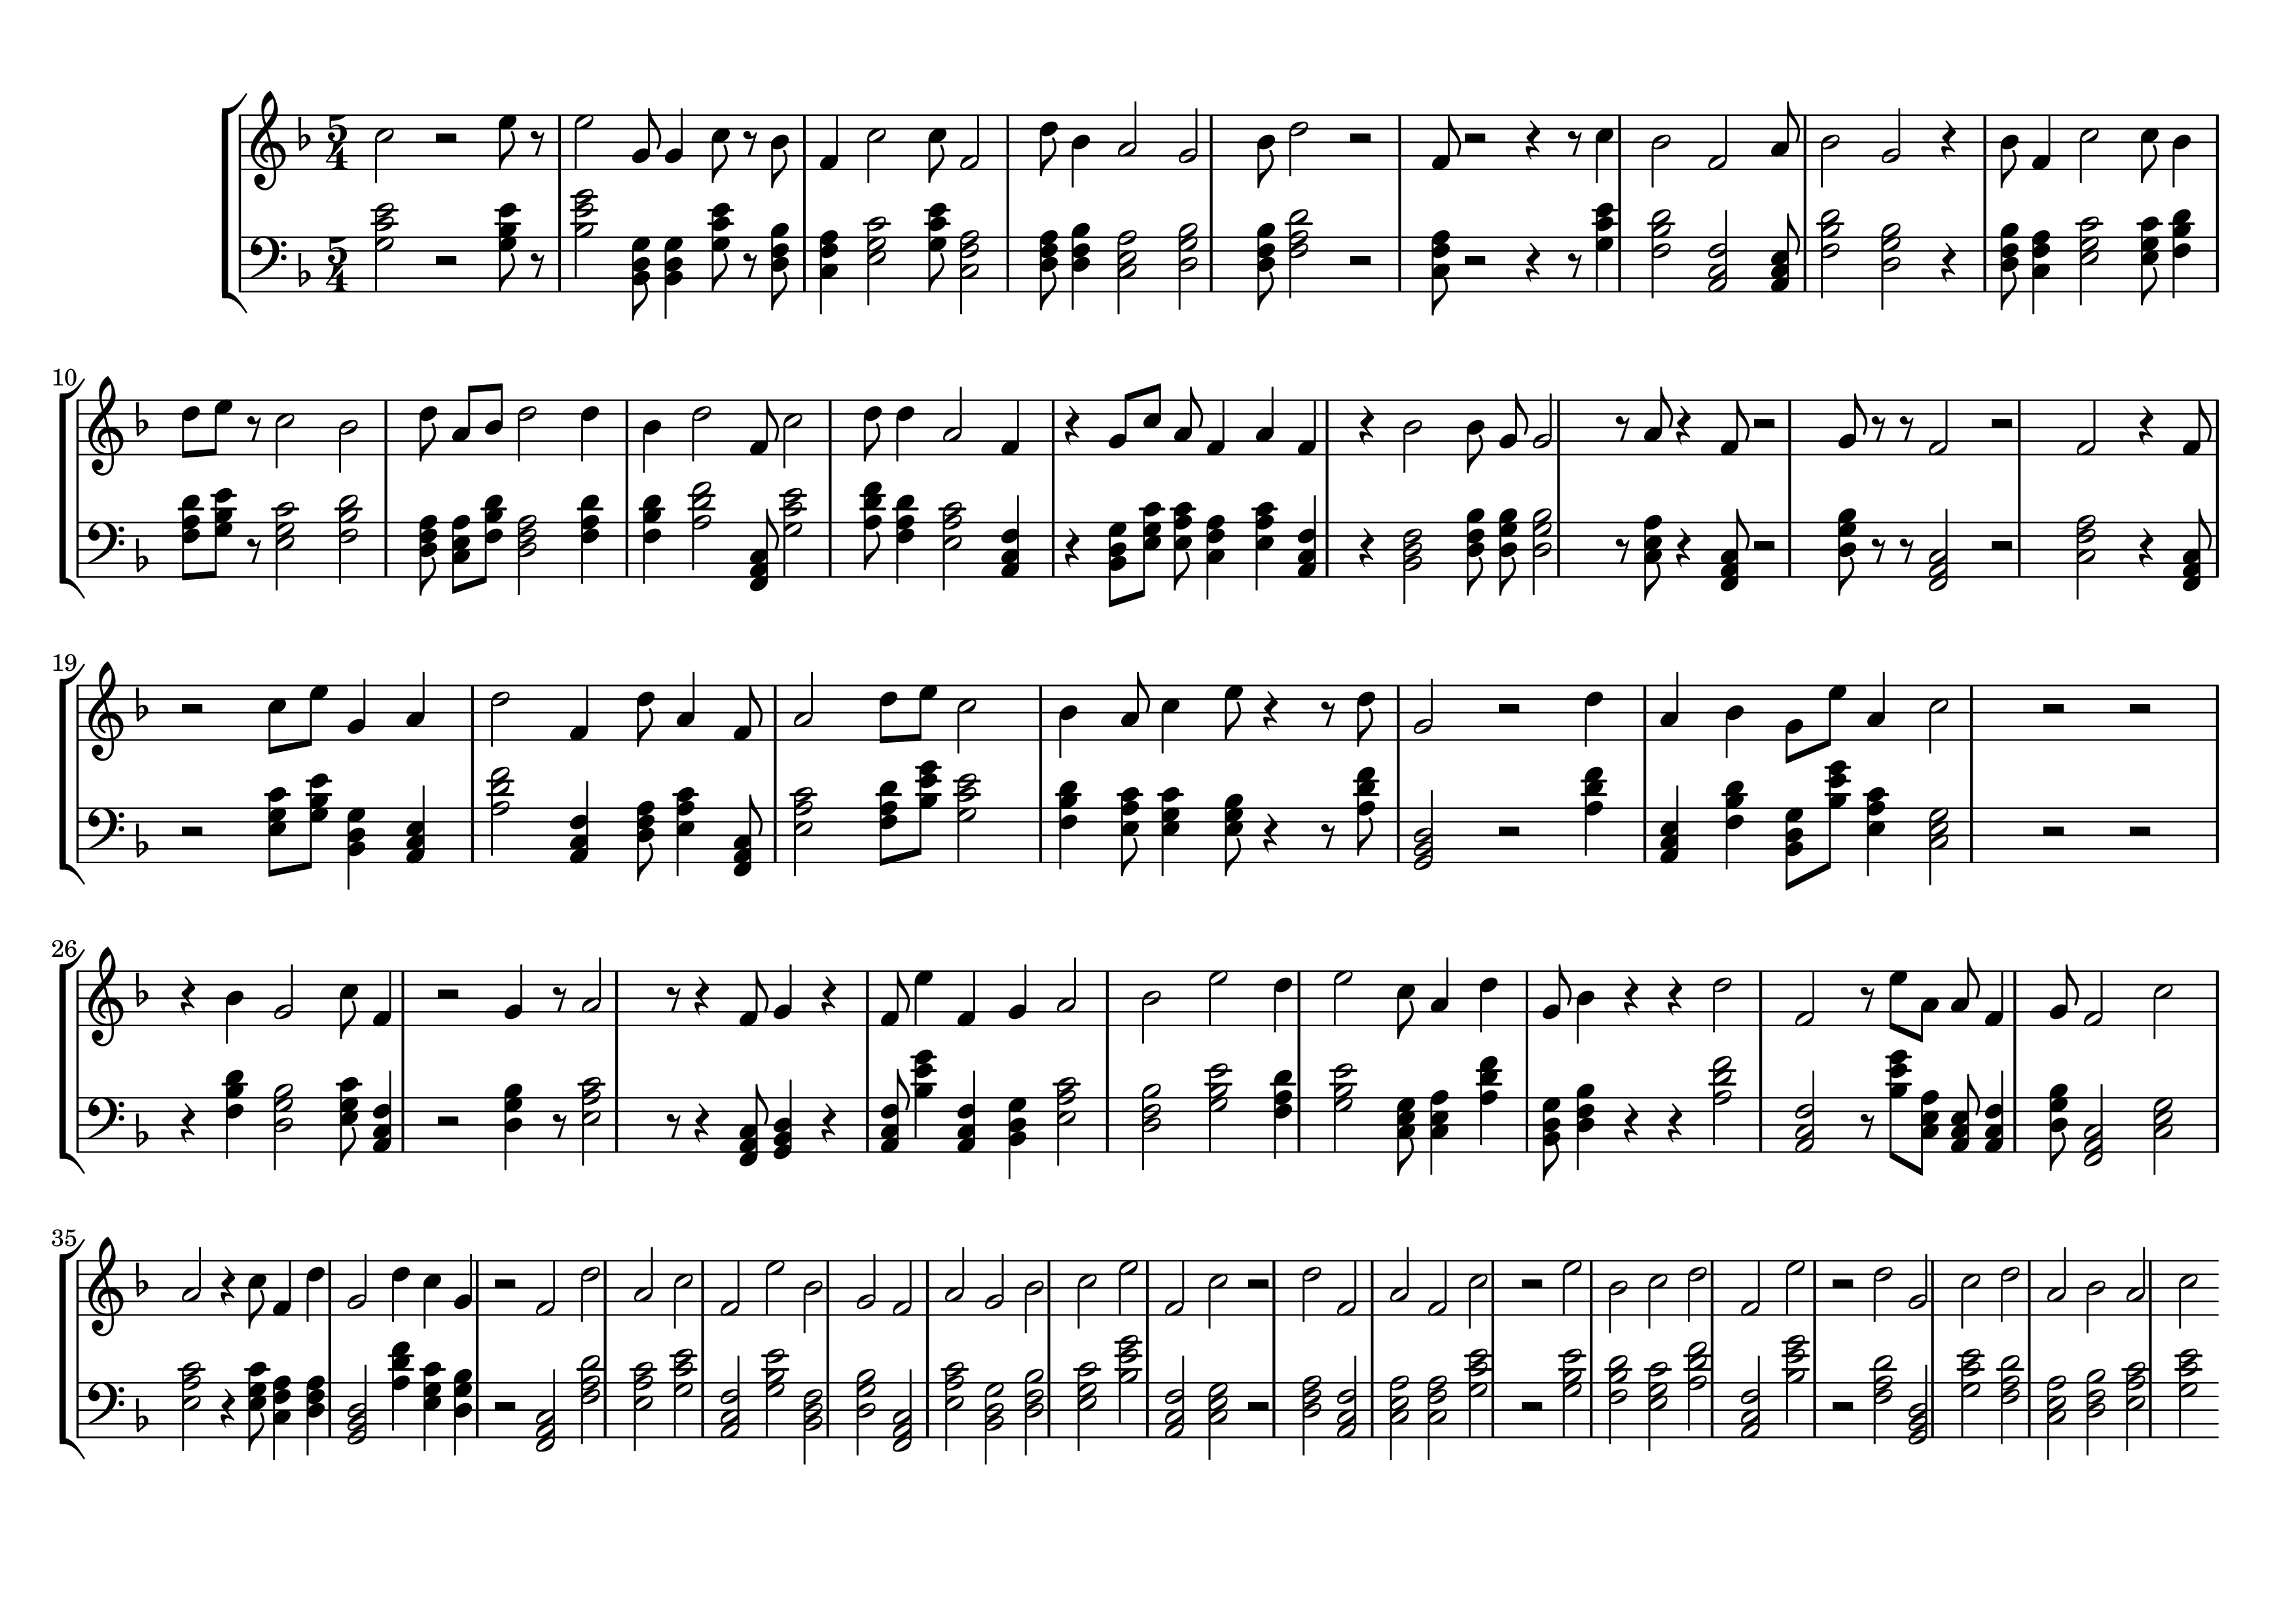

In [9]:
import random as rnd

BATTUTE = 40
N_BEAT = 5
PAUSA = -1

scala = Scale.new(ScaleModel.maj, root=65) # fa maggiore
harmo = scala.harmonize
pattr = Pattern([8, 4, 2])

voice_1 = []
voice_2 = []

durs_1 = []
durs_2 = []

for i in range(BATTUTE):
    for i in range(N_BEAT):

        if rnd.randint(0, 100) > 20:
            nota = rnd.choice(scala)
            voice_1.append(nota)

            durata = rnd.choice(pattr.vals)
            durs_1.append(durata)

            idChord = scala.getids([nota])[0][0]
            chord = harmo[idChord] - 24
            
            inv_choice = rnd.randint(0, 100)

            if inv_choice < 20:
                chord = chord
            if inv_choice >= 20 and inv_choice <= 60:
                chord = chord.first_inv
            if inv_choice > 60:
                chord = chord.second_inv

            voice_2.append(chord.values)
            durs_2.append(durata)
        else:
            # meete una pausa
            voice_1.append(PAUSA)
            voice_2.append(PAUSA)

dx = Staff(voice_1, durs_1, 90, t_sig='5/4', key='f').out
sx = Staff(voice_2, durs_2, 90, t_sig='5/4', key='f', clef='bass').out

Score((dx, sx), filename='./images/faMaggiore', format='png').make_file
Image(filename='./images/faMaggiore.png')

_Set = [16, 2, 8, 4, 16]
_Set = [8, 2, 8, 4, 16]
_Set = [8, 2, 8, 4, 2]
_Set = [8, 16, 8, 4, 2]
_Set = [8, 16, 8, 8, 2]
_Set = [8, 16, 4, 8, 2]


Changing working directory to: `./images'
Processing `./images/old.ly'
Parsing...
Interpreting music...
Preprocessing graphical objects...
Interpreting music...
MIDI output to `old.midi'...
Finding the ideal number of pages...
Fitting music on 1 page...
Drawing systems...
Converting to PNG...
Success: compilation successfully completed


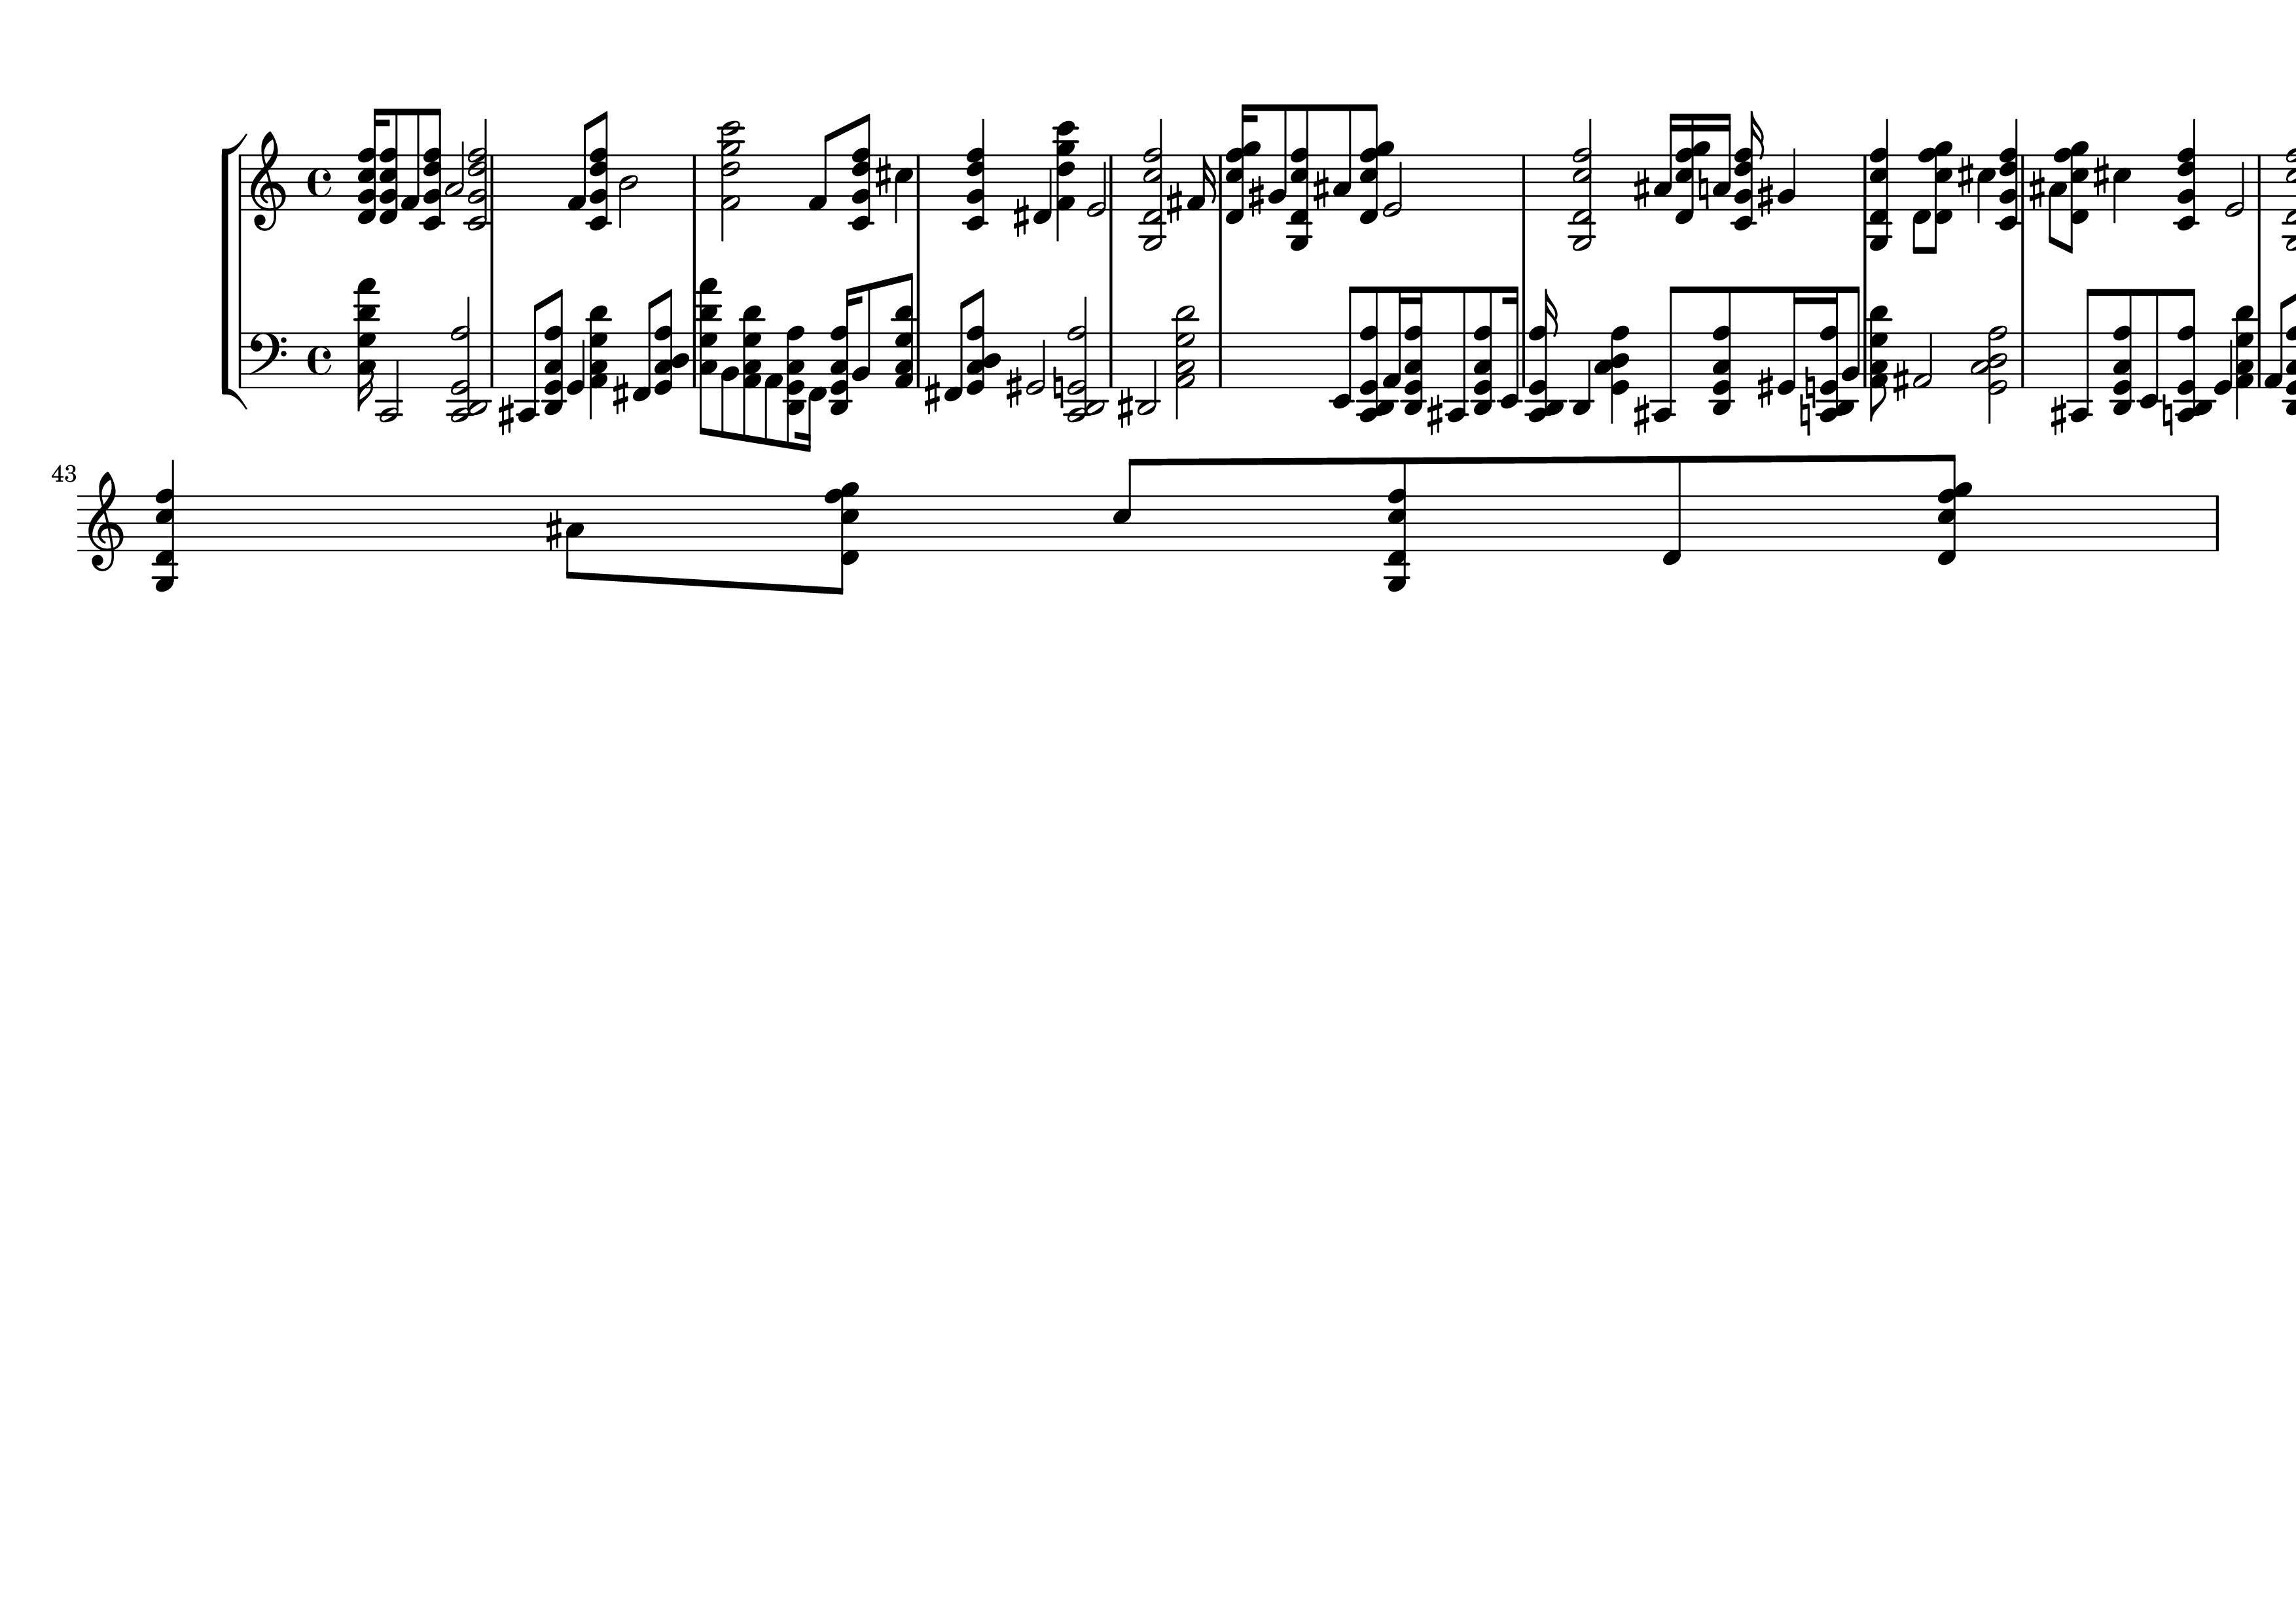

In [ ]:
c1 = Chord.new(ChordModel.quartal, 62)
c2 = Chord.new(ChordModel.quintal, 48)

s1 = Scale.rand_int(12, 0, 12).shift(62)
s2 = Scale.new(ScaleModel.chromatic, 36)

d_1 = Pattern([16, 2, 8, 4, 16])
d_2 = Pattern([8, 16, 4, 8, 2])

morphing = _Set(d_1.vals).morphing(_Set(d_2.vals), 'chiasm')

note_1 = []
note_2 = []
dur_1 = []
dur_2 = []

cicli = 40

for i in range(cicli):
    morph_patt = morphing[i%len(morphing)]
    if i == 0:
        note_1.append(c1)
        note_2.append(c2)
        dur_1.append(morph_patt.vals[0])
        dur_2.append(morph_patt.vals[0])
    else:
        for j in morph_patt:
            if rnd.randint(0, 100) < 5:
                note_1.append(c1)
                dur_1.append(morph_patt.vals[0])
                note_2.append(c2)
                dur_2.append(morph_patt.vals[0])
            else:
                if rnd.randint(0, 100) < 50:
                    n1 = rnd.choice(s1.pitches)
                    note_1.append(n1)
                    dur_1.append(morph_patt.values[n1%5])
                    note_1.append(c1.n_inversion(n1%4).drop3)
                    dur_1.append(morph_patt.values[n1%5])
                else:
                    n2 = rnd.choice(s2.pitches)
                    note_2.append(n2)
                    dur_2.append(morph_patt.values[n2%5])
                    note_2.append(c2.n_inversion(n2%4).shift(-12).drop2)
                    dur_2.append(morph_patt.values[n2%5])

seq_1 = PitchSequence((note_1)).out
seq_2 = PitchSequence((note_2)).out

seq_1 = Staff(seq_1, dur_1, 90).out
seq_2 = Staff(seq_2, dur_2, 90, clef='bass').out

Score((seq_1, seq_2), filename='./images/old', format='png').make_file
Image(filename='./images/old.png')